# 📊 Superstore Sales Analysis

## 📌 Descripción del proyecto

En este proyecto se analiza el dataset Superstore utilizando Python para explorar el comportamiento de ventas, ganancias, clientes y categorías de productos.

El objetivo es identificar patrones, tendencias e insights que permitan comprender el desempeño del negocio y apoyar la toma de decisiones.

Para este análisis se utilizan herramientas como Pandas, Matplotlib y Seaborn para la limpieza, exploración y visualización de datos.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv("superstore.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [4]:
df.shape

(51290, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [6]:
df['sales'] = df['sales'].str.replace(',', '')
df['sales'] = df['sales'].astype(float)

##### Data Cleaning

La columna "sales" estaba almacenada como texto y contenía comas como separadores de miles. 
Se eliminaron las comas y la columna fue convertida a un tipo de dato numérico para permitir cálculos y análisis.

In [7]:
# Las columnas de fechas fueron convertidas a formato datetime para permitir análisis temporales, como ventas por mes, año y tiempos de envío.

df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], format='mixed', dayfirst=True)

In [8]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()
df['shipping_time'] = (df['ship_date'] - df['order_date']).dt.days

In [9]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sales,quantity,discount,profit,shipping_cost,order_priority,year,month,month_name,shipping_time
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,408.0,2,0.0,106.140,35.46,Medium,2011,1,January,5
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,120.0,3,0.1,36.036,9.72,Medium,2011,1,January,7
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,66.0,4,0.0,29.640,8.17,High,2011,1,January,4
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,45.0,3,0.5,-26.055,4.82,High,2011,1,January,4
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,114.0,5,0.1,37.770,4.70,Medium,2011,1,January,7


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  float64       
 15  qu

In [11]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year,month,shipping_time
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208,7.522636,3.969370
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000,1.000000,0.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000,5.000000,3.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000,8.000000,4.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000,10.000000,5.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000,12.000000,7.000000
std,NaN,NaN,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931,3.300056,1.729437


## 📌 Exploratory Data Analysis

### SALES BY YEAR

In [12]:
sales_by_year= df.groupby('year')['sales'].sum()
sales_by_year

year
2011    2259511.0
2012    2677493.0
2013    3405860.0
2014    4300041.0
Name: sales, dtype: float64

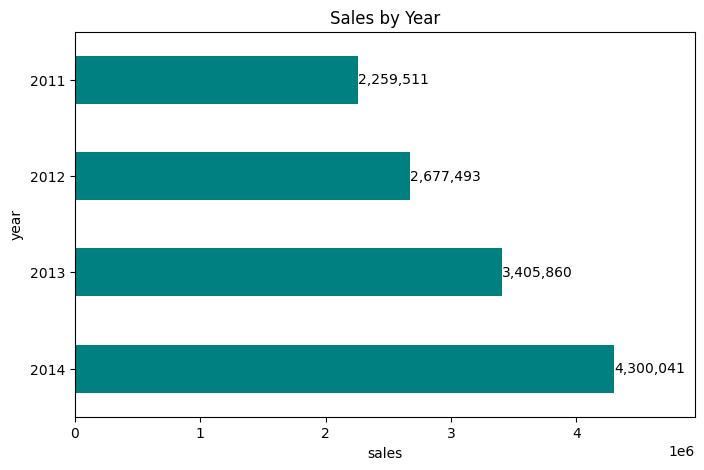

In [13]:
ax = sales_by_year.plot(kind='barh', figsize=(8,5), color='teal')

plt.title("Sales by Year")
plt.xlabel("sales")
plt.ylabel("year")

# mostrar valores al final de las barras
for i, v in enumerate(sales_by_year):
    ax.text(v, i, f'{v:,.0f}', va='center')

# dar más espacio a la derecha del gráfico
ax.set_xlim(0, sales_by_year.max() * 1.15)
ax.invert_yaxis()

plt.show()

### Insight:

Las ventas muestran un crecimiento constante desde el año 2011 hasta el 2014. 
En 2011 las ventas fueron de 2,259,511, mientras que en 2014 alcanzaron los 4,300,041, evidenciando un incremento significativo a lo largo del periodo analizado.

Se observa una tendencia claramente positiva, donde las ventas aumentan año a año, lo que sugiere una expansión sostenida del negocio.

### SALES BY CATEGORY

In [14]:
sales_by_category = df.groupby('category')['sales'].sum().sort_values(ascending=False)
sales_by_category

category
Technology         4744691.0
Furniture          4110884.0
Office Supplies    3787330.0
Name: sales, dtype: float64

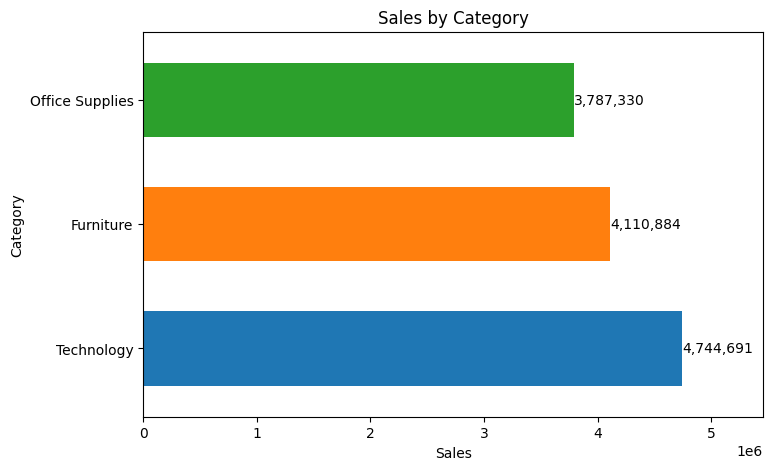

In [15]:
colors = plt.cm.tab10(range(len(sales_by_category)))

ax = sales_by_category.plot(
    kind='barh',
    figsize=(8,5),
    color=colors,
    width=0.6   # esto hace las barras más delgadas
)

plt.title("Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")

# escribir valores al final de cada barra
for i, v in enumerate(sales_by_category):
    ax.text(v, i, f'{v:,.0f}', va='center')

# dar espacio a la derecha para que entren los números
ax.set_xlim(0, sales_by_category.max() * 1.15)

plt.show()

### Insight:
La categoría Technology presenta el mayor volumen de ventas, seguida por Furniture y Office Supplies. 
Esto indica que los productos tecnológicos son la principal fuente de ingresos de la empresa.

Sin embargo, la diferencia entre las categorías no es extremadamente amplia, lo que sugiere que las ventas están relativamente diversificadas y la empresa no depende únicamente de una sola categoría de productos.

### PROFIT BY CATEGORY

In [16]:
profit_by_category = (
    df.groupby('category')['profit']
    .sum()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

profit_by_category

,category,profit
0,Technology,663778.73
1,Office Supplies,518473.83
2,Furniture,286782.25


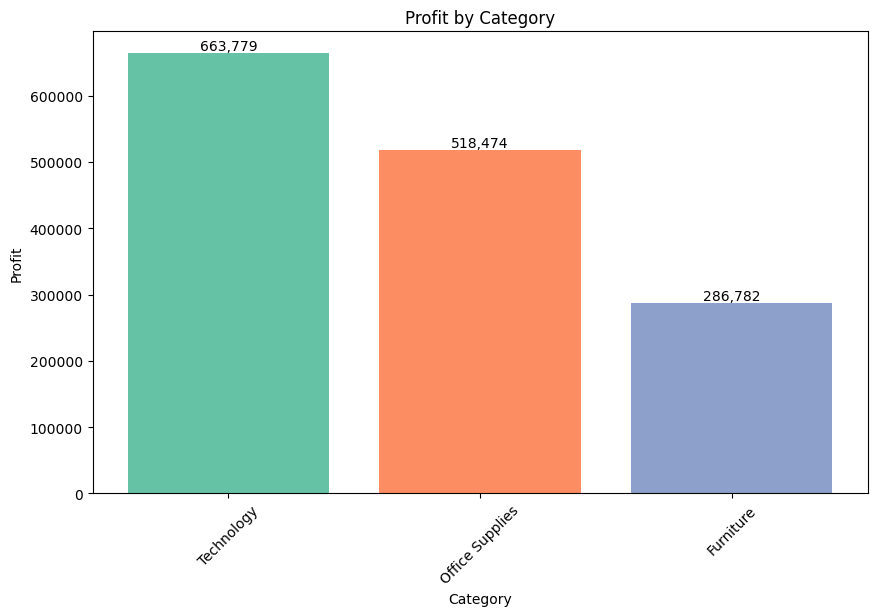

In [17]:
colors = plt.cm.Set2(np.arange(len(profit_by_category)))

plt.figure(figsize=(10,6))
bars = plt.bar(profit_by_category["category"], profit_by_category["profit"], color=colors)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:,.0f}', 
             ha='center', va='bottom')

plt.show()

### Insight:
La categoría Technology genera el mayor profit para la empresa, lo que indica que además de tener altas ventas, también presenta buenos márgenes de ganancia.

Office Supplies, aunque no es la categoría con mayores ventas, genera más profit que Furniture, lo que sugiere que los productos de Office Supplies tienen mejores márgenes de rentabilidad. 

Por otro lado, Furniture presenta un profit considerablemente menor en comparación con sus ventas, lo que podría indicar costos altos, descuentos elevados o márgenes de ganancia más bajos en esta categoría.

Esto sugiere que no necesariamente la categoría con mayores ventas es la más rentable para la empresa.

### SALES BY REGION

In [18]:
sales_by_region = (
    df.groupby('region')['sales']
    .sum()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

sales_by_region

,region,sales
0,Central,2822399.0
1,South,1600960.0
2,North,1248192.0
3,Oceania,1100207.0
4,Southeast Asia,884438.0
5,North Asia,848349.0
6,EMEA,806184.0
7,Africa,783776.0
8,Central Asia,752839.0
9,West,725514.0


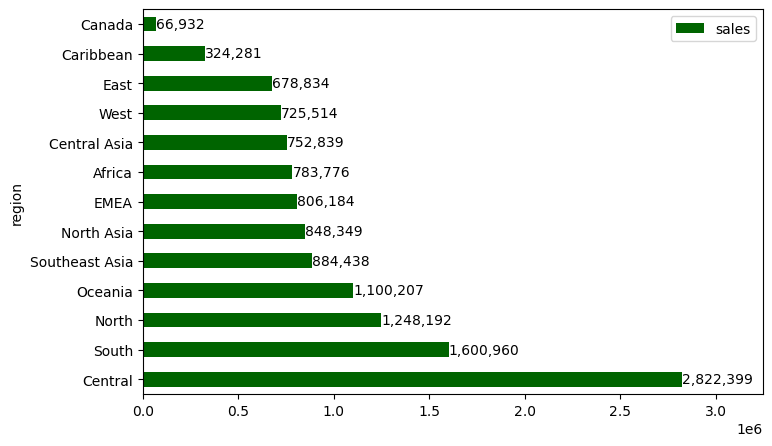

In [19]:
ax = sales_by_region.plot(kind='barh', x='region', y='sales', figsize=(8,5), color='darkgreen')

for i, v in enumerate(sales_by_region['sales']):
    ax.text(v, i, f'{v:,.0f}', va='center')

ax.set_xlim(0, sales_by_region['sales'].max() * 1.15)

plt.show()

### Insight:

El análisis de ventas por región muestra que la región Central concentra el mayor volumen de ventas, seguida por South y North, lo que indica que estas regiones son los mercados más importantes para la empresa.

Las regiones con menores ventas, como Caribbean y Canada, podrían representar oportunidades de crecimiento si la empresa decide expandir su presencia comercial en estos mercados.

La distribución de las ventas por región sugiere que la empresa tiene una presencia internacional diversificada, aunque con una fuerte concentración en ciertas regiones, lo cual puede representar tanto una fortaleza como un riesgo si la empresa depende demasiado de estos mercados principales.

### SALES BY SEGMENT

In [20]:
sales_by_segment = (
df.groupby('segment')['sales']
.sum()
.sort_values(ascending=False)
.reset_index()
)

sales_by_segment

,segment,sales
0,Consumer,6508141.0
1,Corporate,3824808.0
2,Home Office,2309956.0


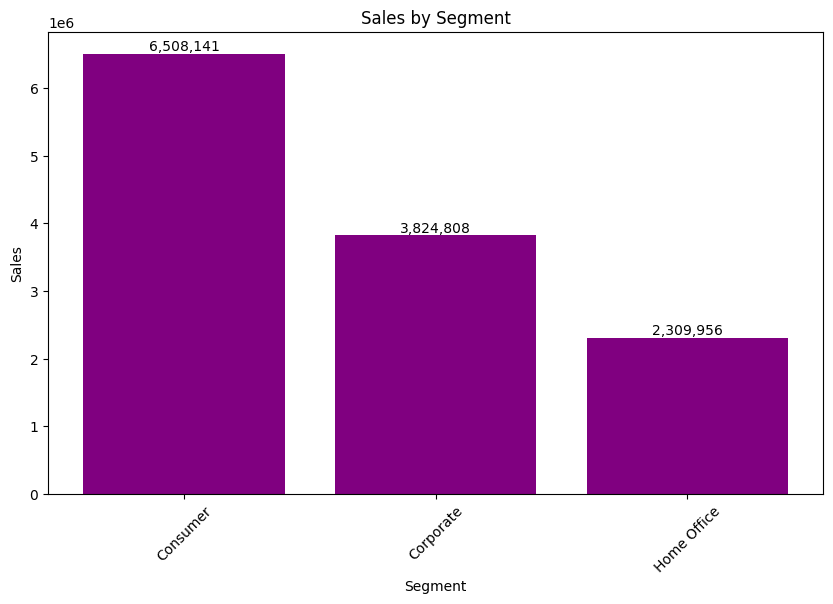

In [21]:
plt.figure(figsize=(10,6))
bars = plt.bar(sales_by_segment["segment"], sales_by_segment["sales"], color='purple')

plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:,.0f}', 
             ha='center', va='bottom')

plt.show()

### Insight:

El segmento Consumer genera la mayor parte de las ventas totales de la empresa, representando el mercado más importante en términos de ingresos. El segmento Corporate ocupa el segundo lugar, lo que indica que las empresas también constituyen una fuente relevante de ventas. Por otro lado, el segmento Home Office presenta el menor volumen de ventas, lo que sugiere que este segmento tiene menor participación en el mercado.

Este resultado indica que la empresa depende principalmente de los consumidores individuales, por lo que las estrategias comerciales y de marketing deberían enfocarse principalmente en este segmento, sin dejar de considerar oportunidades de crecimiento en los segmentos Corporate y Home Office.


### SHIPPING TIME

In [22]:
shipping_time = (
df.groupby('ship_mode')['shipping_time']
.mean()
.sort_values(ascending=False)
.reset_index()
)

shipping_time

,ship_mode,shipping_time
0,Standard Class,4.998018
1,Second Class,3.230187
2,First Class,2.181746
3,Same Day,0.037394


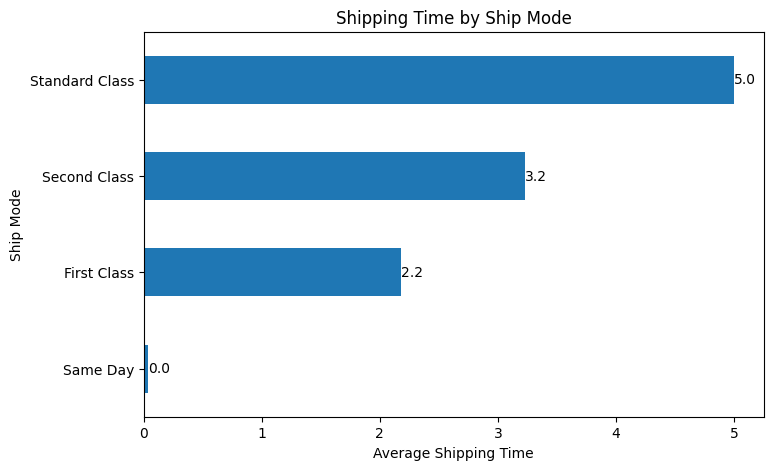

In [23]:
ax = shipping_time.plot(
    kind='barh',
    x='ship_mode',
    y='shipping_time',
    figsize=(8,5),
    legend=False
)

plt.title("Shipping Time by Ship Mode")
plt.xlabel("Average Shipping Time")
plt.ylabel("Ship Mode")

for i, v in enumerate(shipping_time['shipping_time']):
    ax.text(v, i, f'{v:.1f}', va='center')

ax.invert_yaxis()

plt.show()

### Insight:

El método de envío Standard Class presenta el mayor tiempo promedio de entrega, mientras que Same Day es el más rápido. First Class y Second Class se encuentran en tiempos intermedios. Esto confirma que los métodos de envío más económicos tienen tiempos de entrega más largos, mientras que los envíos más rápidos reducen significativamente el tiempo de entrega.

### TOP 10 PRODUCTS

In [24]:
top_products = (
df.groupby('product_name')['sales']
.sum()
.sort_values(ascending=False)
.head(10)
.reset_index()
)

top_products

,product_name,sales
0,"Apple Smart Phone, Full Size",86936.0
1,"Cisco Smart Phone, Full Size",76441.0
2,"Motorola Smart Phone, Full Size",73159.0
3,"Nokia Smart Phone, Full Size",71904.0
4,Canon imageCLASS 2200 Advanced Copier,61600.0
5,"Hon Executive Leather Armchair, Adjustable",58200.0
6,"Office Star Executive Leather Armchair, Adjust...",50667.0
7,"Harbour Creations Executive Leather Armchair, ...",50120.0
8,"Samsung Smart Phone, Cordless",48654.0
9,"Nokia Smart Phone, with Caller ID",47880.0


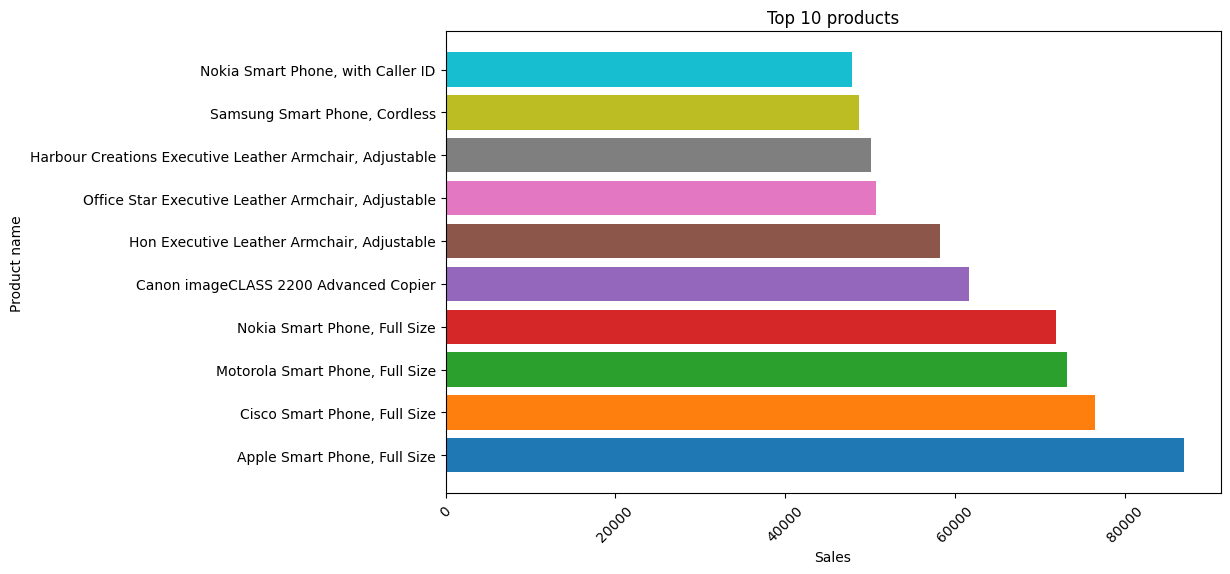

In [25]:
colors = plt.cm.tab10(np.arange(10))

plt.figure(figsize=(10,6))
plt.barh(top_products["product_name"], top_products["sales"], color=colors)

plt.title("Top 10 products")
plt.xlabel("Sales")
plt.ylabel("Product name")

plt.xticks(rotation=45)
plt.show()

### Insight:

Los productos con mayores ventas están dominados principalmente por smartphones y sillas ejecutivas, lo que indica que la empresa obtiene una gran parte de sus ingresos de productos tecnológicos y mobiliario de oficina. Esto sugiere que estos productos son los más demandados y representan una parte importante del negocio, por lo que la empresa debería mantener un buen nivel de inventario y estrategias de venta enfocadas en estos productos.

### PROFIT MARGIN

In [26]:
sales_profit_category = (
    df.groupby('category')[['sales','profit']]
    .sum()
    .reset_index()
)
sales_profit_category

,category,sales,profit
0,Furniture,4110884.0,286782.25380
1,Office Supplies,3787330.0,518473.83430
2,Technology,4744691.0,663778.73318


In [27]:
sales_profit_category['profit_margin'] = (
    sales_profit_category['profit'] /
    sales_profit_category['sales']
)
sales_profit_category

,category,sales,profit,profit_margin
0,Furniture,4110884.0,286782.25380,0.069762
1,Office Supplies,3787330.0,518473.83430,0.136897
2,Technology,4744691.0,663778.73318,0.139899


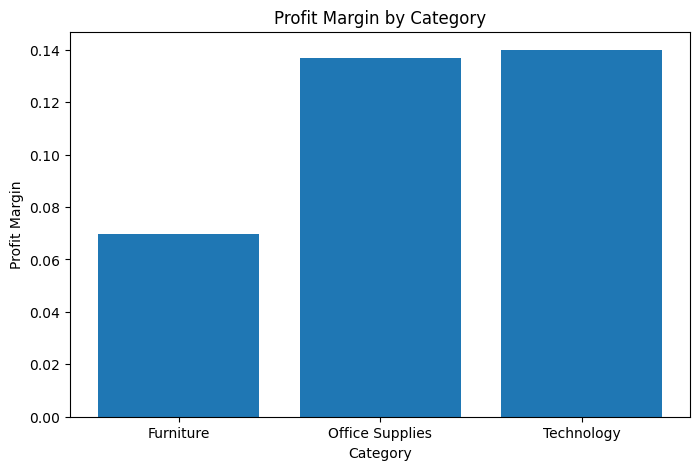

In [28]:
plt.figure(figsize=(8,5))
plt.bar(sales_profit_category['category'],
        sales_profit_category['profit_margin'])

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin")

plt.show()

### Insight:

El análisis del margen de utilidad por categoría muestra que Technology y Office Supplies tienen los mayores márgenes de ganancia, mientras que Furniture presenta el margen más bajo a pesar de tener un alto volumen de ventas. Esto indica que Furniture genera muchas ventas pero menor rentabilidad, mientras que Technology es la categoría más rentable para la empresa.

## Conclusions

A lo largo del análisis se observó que las ventas de la empresa han crecido de manera constante a lo largo de los años, mostrando una tendencia positiva en el desempeño del negocio. La categoría Technology se posiciona como la más importante tanto en ventas como en profit, mientras que Furniture, a pesar de generar un alto volumen de ventas, presenta un margen de utilidad más bajo.

Las ventas se concentran principalmente en el segmento Consumer y en ciertas regiones específicas, lo que indica que estos mercados representan la mayor fuente de ingresos para la empresa. Además, el análisis de los productos más vendidos muestra que los productos tecnológicos y mobiliario de oficina son los más demandados.

En general, la empresa muestra un crecimiento sostenido y una buena rentabilidad en ciertas categorías, por lo que las estrategias futuras podrían enfocarse en fortalecer las categorías más rentables y mejorar la rentabilidad de aquellas con alto volumen de ventas pero bajo margen de ganancia.